# Model Training

Calls `src/models.py` and `src/train.py` functions. No logic lives here.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
import config
from src.models import HARModel, HARPooled, LSTMModel, GNNModel
from src.train import set_seeds, train_lstm, train_gnn

## HAR Baselines

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from src.models import compute_har_features, prepare_har_arrays

weekly_rv = pd.read_parquet(Path(config.DATA_RAW_DIR) / "weekly_rv.parquet")
target    = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / "target.parquet")
splits    = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / "splits.parquet")
print(f"weekly_rv: {weekly_rv.shape}, target: {target.shape}, splits: {splits.shape}")

weekly_rv: (573, 50), target: (572, 50), splits: (572, 2)


In [3]:
rv_1w, rv_4w, rv_13w = compute_har_features(weekly_rv)
print(f"RV_13w grand mean (excl. NaN): {rv_13w.stack().mean():.4f}")
print(f"NaN weeks at start (rv_13w): {rv_13w.isna().all(axis=1).sum()}")

RV_13w grand mean (excl. NaN): 0.2386
NaN weeks at start (rv_13w): 12


In [4]:
X_train, y_train, Xp_train, yp_train, train_idx = prepare_har_arrays(
    rv_1w, rv_4w, rv_13w, target, splits, "train"
)
X_val, y_val, Xp_val, yp_val, val_idx = prepare_har_arrays(
    rv_1w, rv_4w, rv_13w, target, splits, "val"
)
print(f"Train: {len(train_idx)} weeks | Val: {len(val_idx)} weeks")
print(f"Pooled train: {Xp_train.shape}, Pooled val: {Xp_val.shape}")

Train: 405 weeks | Val: 52 weeks
Pooled train: (20250, 3), Pooled val: (2600, 3)


In [5]:
har = HARModel()
har.fit(X_train, y_train)

har_pooled = HARPooled()
har_pooled.fit(Xp_train, yp_train)
print("HARModel and HARPooled fitted.")

HARModel and HARPooled fitted.


In [6]:
tickers       = target.columns.tolist()
num_val_weeks = len(val_idx)
num_stocks    = len(tickers)

har_preds_dict = har.predict(X_val)
har_val_df     = pd.DataFrame(har_preds_dict, index=val_idx)[tickers]

pooled_raw         = har_pooled.predict(Xp_val)
har_pooled_val_df  = pd.DataFrame(
    pooled_raw.reshape(num_val_weeks, num_stocks), index=val_idx, columns=tickers
)
print(f"HAR val preds: {har_val_df.shape}, Pooled val preds: {har_pooled_val_df.shape}")

HAR val preds: (52, 50), Pooled val preds: (52, 50)


In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

target_val = target.loc[val_idx]

har_mse  = mean_squared_error(target_val.values.ravel(), har_val_df.values.ravel())
har_mae  = mean_absolute_error(target_val.values.ravel(), har_val_df.values.ravel())
pool_mse = mean_squared_error(target_val.values.ravel(), har_pooled_val_df.values.ravel())
pool_mae = mean_absolute_error(target_val.values.ravel(), har_pooled_val_df.values.ravel())

print(f"HAR per-stock — Val MSE: {har_mse:.6f}  MAE: {har_mae:.6f}")
print(f"HAR pooled    — Val MSE: {pool_mse:.6f}  MAE: {pool_mae:.6f}")

HAR per-stock — Val MSE: 0.015978  MAE: 0.092246
HAR pooled    — Val MSE: 0.015718  MAE: 0.091020


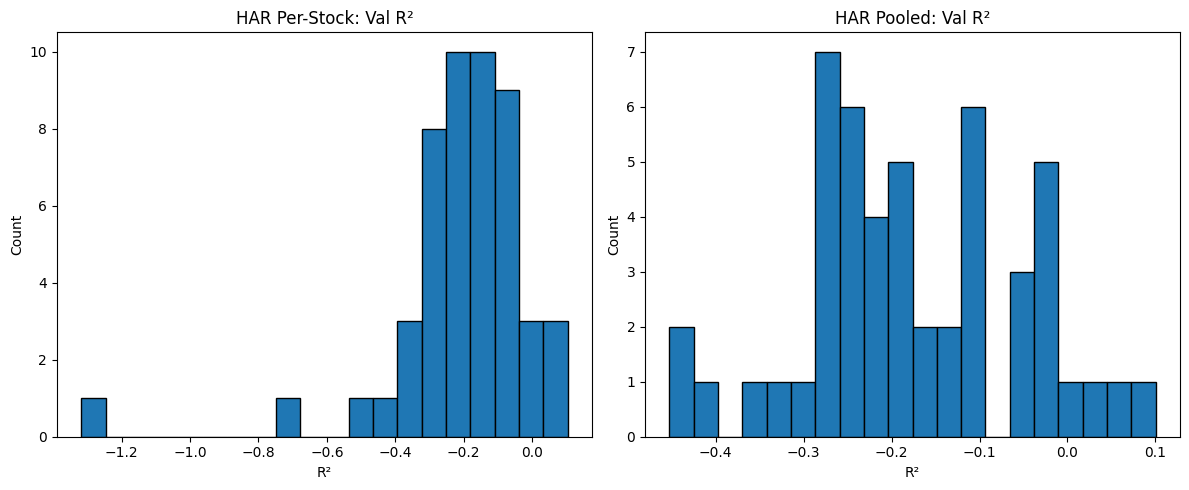

Per-stock R²: median=-0.181  mean=-0.209
Pooled    R²: median=-0.197  mean=-0.177


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

har_r2  = [r2_score(target_val[t].values, har_val_df[t].values) for t in tickers]
pool_r2 = [r2_score(target_val[t].values, har_pooled_val_df[t].values) for t in tickers]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(har_r2,  bins=20, edgecolor="k")
axes[0].set_title("HAR Per-Stock: Val R²")
axes[0].set_xlabel("R²"); axes[0].set_ylabel("Count")
axes[1].hist(pool_r2, bins=20, edgecolor="k")
axes[1].set_title("HAR Pooled: Val R²")
axes[1].set_xlabel("R²"); axes[1].set_ylabel("Count")
plt.tight_layout(); plt.show()
print(f"Per-stock R²: median={np.median(har_r2):.3f}  mean={np.mean(har_r2):.3f}")
print(f"Pooled    R²: median={np.median(pool_r2):.3f}  mean={np.mean(pool_r2):.3f}")

In [9]:
results_dir = Path(config.DATA_RESULTS_DIR)
results_dir.mkdir(parents=True, exist_ok=True)

assert har_val_df.shape       == (num_val_weeks, num_stocks), f"Shape error: {har_val_df.shape}"
assert har_pooled_val_df.shape == (num_val_weeks, num_stocks), f"Shape error: {har_pooled_val_df.shape}"

har_val_df.to_parquet(results_dir / "har_val_preds.parquet")
har_pooled_val_df.to_parquet(results_dir / "har_pooled_val_preds.parquet")
print(f"Saved har_val_preds.parquet and har_pooled_val_preds.parquet → {results_dir}/")

Saved har_val_preds.parquet and har_pooled_val_preds.parquet → C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results/
